# OpenKind — Qwen MoE quality and cache follow-up
**Experiment notebook v0.1 · evidence reviewed 26 September 2026 (America/Chicago)**

The previous experiment established an engineering trade-off and exposed an unreliable cache path. This follow-up asks **why the native decision model misses evidence, whether selected-expert scale contributed to top-k regressions, and where full/split inference diverges**.

**Colab:** open a fresh GPU runtime and Run all. Default: the exact Qwen1.5-MoE checkpoint from the inspected L4 run, NF4 weights, BF16 computation when supported. A larger GPU can run the optional Qwen3 profile as a separate study. Drive persistence is **on by default**; generated evidence goes to `Colab Notebooks/OpenKind_MoE_Lab/followup_runs`. The small reviewed source bundle is embedded, so no manual evidence download is required.

Without CUDA, this notebook exercises tiny **random-weight** Qwen models. Their outputs validate the code path only. The author executed those checks locally; **the new pretrained GPU/NF4 experiments are unrun**. No training, physical pruning, actual expert streaming, or Qwen3.5 hybrid-cache adaptation is included.

## 1. What the inspected evidence established

Drive source: [20260926T224132_613995Z](https://drive.google.com/drive/folders/1344_xljzgYaHEWJTUVEe7k3_2DXoM3Fi).

| Observation | Evidence |
|---|---|
| Native decision quality is insufficient on these teaching fixtures | 18/32 correct; **0/8 unknown cases detected**; zero automatic acceptance |
| Late-block skipping has mixed effects | 17/32; two correct answers lost, one gained, four predictions changed |
| Sparse per-token compute is not a small request working set | **59.33/60 experts per layer per request**, mean across 384 layer-request observations |
| Temperature selection hit its bound | All seven arms selected **T=5**, the maximum searched |
| Prefix reuse is unqualified | Four of eight checks fail; max Δp **0.119915**; one decision flips |
| Selected output rows preserve the measured readout | All 16 comparisons have Δp=0, but no measured median latency improvement |

The later completed run (`20260926T232551_755243Z`) was supplied as a chat table. Its approximately 3.0 GiB memory reduction is **user-reported evidence**; the visible Drive run stops before removal and has no raw removal or updated cache diagnostic files. This notebook does not silently merge the two runs.

## 2. Lock the experiment

Only development data choose the prompt and candidate. Calibration and review-policy fitting have separate source groups. The final split has fresh entities and held-out wording, with equal Yes / No / Unknown counts. Numerical values can recur across splits. These remain **authored fixtures**, not independent real-world generalization evidence.

The candidate is the fastest development arm meeting the declared accuracy, unknown-recall and speed conditions. If none qualifies, the final evaluation reports the native baseline alone. The final research thresholds are explicit planning choices, not production safety guarantees. Never retune them after viewing final results; use a new preregistered run and new data.

In [4]:
import os, sys
PROFILE = "qwen15_moe"  # @param ["qwen15_moe", "qwen3_moe"]
PRECISION = "nf4"  # @param ["nf4", "bf16"]
MODEL_REVISION = ""  # Empty pins Qwen1.5 to the inspected run; Qwen3 resolves once to a SHA.
MOUNT_GOOGLE_DRIVE = True  # @param {type:"boolean"}
AUTO_SMOKE_ON_CPU = True
MAX_INPUT_TOKENS = 768
TIMING_REPEATS = 2
WARMUP_CALLS = 1
SEED = 73129
REVIEW_COST = 0.10
DEV_MAX_ACCURACY_LOSS = 0.02
DEV_MAX_NONE_RECALL_LOSS = 0.05
MIN_FINAL_ACCURACY = 0.80  # Research targets, not validated production requirements.
MIN_FINAL_NONE_RECALL = 0.80
MIN_FINAL_COVERAGE = 0.20
MAX_FINAL_ACCEPTED_ERROR = 0.10
MIN_SPEEDUP = 1.10
RUN_CACHE_NUMERICS = True
RUN_NF4_REFERENCE = True   # A slow FP32 linear reference over the SAME NF4 weights; not full FP32/BF16.
RUN_PROFILER = True
RUN_OPTION_ORDER_CHECK = True
BOOTSTRAP_REPEATS = 2000
SKIP_COUNTS = [1, 2, 4, 6]
GROUPS_PER_SPLIT = {'prompt_dev':8, 'selection_dev':12, 'calibration':16, 'policy_dev':16, 'test':32}
DOWNLOAD_ARCHIVE = False

SMOKE_REQUESTED = os.environ.get('OPENKIND_MOE_SMOKE')=='1'
SKIP_INSTALL = os.environ.get('OPENKIND_SKIP_INSTALL')=='1'
PROFILE = os.environ.get('OPENKIND_MOE_PROFILE',PROFILE)
if PROFILE=='qwen15_moe' and not MODEL_REVISION:
    MODEL_REVISION='ec052fda178e241c7c443468d2fa1db6618996be'
# Kept for compatibility with the audited loader; no allowlist/pruning/length experiment runs here.
ALLOWLIST_FRACTION=0.5
RUN_LENGTH_STUDY=False
EXTRA_CONTEXT_TOKENS=[]

## 3. Install and record the runtime

Keep Colab's PyTorch/CUDA pair. The audited Transformers and bitsandbytes implementations are pinned. Restart first if a conflicting version was already imported. The loader admits one resident GPU model and never silently offloads it to CPU. It checks memory/disk before a fresh weight download.

In [5]:
import importlib.metadata as metadata
import subprocess
required = {"transformers":"4.57.1", "accelerate":"1.10.1", "bitsandbytes":"0.48.1"}
if not SKIP_INSTALL:
    for name, wanted in required.items():
        if name in sys.modules and metadata.version(name) != wanted:
            raise RuntimeError(f"Restart the session: {name} is already imported at a different version.")
    pending=[]
    for name, wanted in required.items():
        try: installed=metadata.version(name)
        except metadata.PackageNotFoundError: installed=None
        if installed != wanted: pending.append(f"{name}=={wanted}")
    if pending:
        subprocess.check_call([sys.executable,"-m","pip","install","-q",*pending])
    for name in ["pandas","matplotlib","psutil","safetensors","scipy"]:
        try: metadata.version(name)
        except metadata.PackageNotFoundError:
            subprocess.check_call([sys.executable,"-m","pip","install","-q",name])
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_DOWNLOAD_TIMEOUT", "120")

'120'

In [6]:
import copy, gc, hashlib, inspect, json, math, platform, random, shutil, time, types, warnings
from collections import OrderedDict, defaultdict
from contextlib import contextmanager
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import torch
import torch.nn.functional as F
import transformers
from transformers import (AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
                          Qwen2MoeConfig, Qwen2MoeForCausalLM, Qwen3MoeConfig, Qwen3MoeForCausalLM)
from huggingface_hub import HfApi, hf_hub_download
from IPython.display import display, Markdown
assert transformers.__version__ == "4.57.1", "This adapter requires the pinned implementation."
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
SMOKE = SMOKE_REQUESTED or (AUTO_SMOKE_ON_CPU and not torch.cuda.is_available())
DEVICE = torch.device("cpu" if SMOKE else "cuda:0")
if not SMOKE and not torch.cuda.is_available():
    raise RuntimeError("Select a Colab GPU or enable the clearly labeled CPU smoke mode.")
if SMOKE:
    torch.set_num_threads(2)
    MAX_INPUT_TOKENS=max(MAX_INPUT_TOKENS, 2048)
    TIMING_REPEATS=1
    WARMUP_CALLS=1
    print("SMOKE ONLY: tiny random Qwen weights. Accuracy and timing are NOT pretrained-model evidence.")
if MOUNT_GOOGLE_DRIVE and not SMOKE:
    from google.colab import drive
    drive.mount('/content/drive')
    base=Path('/content/drive/MyDrive/Colab Notebooks/OpenKind_MoE_Lab/followup_runs')
else:
    base=Path('/content/openkind_moe_followup_runs') if Path('/content').exists() else Path.cwd()/'openkind_moe_followup_runs'
RUN_DIR=base/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN_DIR.mkdir(parents=True, exist_ok=False)

def save_json(name, obj):
    target=RUN_DIR/name
    temp=target.with_suffix(target.suffix+'.tmp')
    temp.write_text(json.dumps(obj, indent=2, ensure_ascii=False, allow_nan=False))
    temp.replace(target)

def sync():
    if DEVICE.type=='cuda': torch.cuda.synchronize(DEVICE)

def memory_snapshot():
    sync()
    try: rss=psutil.Process().memory_info().rss/2**30
    except (psutil.Error, PermissionError, FileNotFoundError): rss=None
    return {"cuda_allocated_gib":torch.cuda.memory_allocated(DEVICE)/2**30 if DEVICE.type=='cuda' else None,
            "cuda_reserved_gib":torch.cuda.memory_reserved(DEVICE)/2**30 if DEVICE.type=='cuda' else None,
            "process_rss_gib":rss}

plt.rcParams.update({'figure.figsize':(9,4.5),'font.size':11,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.18})
BLUE='#285E8E'; GOLD='#B88624'; ORANGE='#C86332'; CHARCOAL='#333B43'
MANIFEST={'notebook_version':'quality-cache-followup-0.1','started_utc':datetime.now(timezone.utc).isoformat(),
          'smoke_only':SMOKE,'profile':PROFILE,'precision_requested':PRECISION,
          'seed':SEED,'max_input_tokens':MAX_INPUT_TOKENS,'timing_repeats':TIMING_REPEATS,
          'review_cost':REVIEW_COST,'allowlist_fraction':ALLOWLIST_FRACTION,
          'run_length_study':RUN_LENGTH_STUDY,'extra_context_tokens':EXTRA_CONTEXT_TOKENS,
          'python':sys.version,'platform':platform.platform(),
          'torch':torch.__version__,'transformers':transformers.__version__,
          'cuda_runtime':torch.version.cuda,
          'gpu':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else None,
          'packages':{x:metadata.version(x) for x in ['transformers','accelerate','numpy','pandas','scipy']}}
save_json('manifest.json', MANIFEST)
print('Output:', RUN_DIR)
display(pd.DataFrame([memory_snapshot()]))
try: MANIFEST["packages"]["bitsandbytes"]=metadata.version("bitsandbytes")
except metadata.PackageNotFoundError: MANIFEST["packages"]["bitsandbytes"]=None

MANIFEST["experiment_settings"]={k:globals()[k] for k in ["GROUPS_PER_SPLIT","SKIP_COUNTS","DEV_MAX_ACCURACY_LOSS","DEV_MAX_NONE_RECALL_LOSS","MIN_FINAL_ACCURACY","MIN_FINAL_NONE_RECALL","MIN_FINAL_COVERAGE","MAX_FINAL_ACCEPTED_ERROR","MIN_SPEEDUP","RUN_CACHE_NUMERICS","RUN_NF4_REFERENCE","RUN_PROFILER"]}
save_json("manifest.json",MANIFEST)

Mounted at /content/drive
Output: /content/drive/MyDrive/Colab Notebooks/OpenKind_MoE_Lab/followup_runs/20260927T003918_481825Z


,cuda_allocated_gib,cuda_reserved_gib,process_rss_gib
0,0.0,0.0,1.606861


## 4. Verify the embedded Drive evidence

This is a byte-preserving snapshot of the 19 source files used for the review, plus provenance and the derived audit. The archive and its individual files are hashed. The original dataset digest must match its runtime manifest. Historical logits are diagnostic inputs only; they do not select a new prompt, candidate, or threshold.

In [7]:
import base64,io,zipfile
PRIOR_BUNDLE_SHA256='7168962d24ea477dc4ed078757d6339e910118fe01cc8a4ad3285e1d205dbbc5'
_evidence_bytes=base64.b64decode('...')
assert hashlib.sha256(_evidence_bytes).hexdigest()==PRIOR_BUNDLE_SHA256
PRIOR_DIR=RUN_DIR/'prior_evidence';PRIOR_DIR.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(_evidence_bytes)) as z:
    for item in z.infolist():
        assert '/' not in item.filename and '\\' not in item.filename
        (PRIOR_DIR/item.filename).write_bytes(z.read(item))
del _evidence_bytes
PRIOR_MANIFEST=json.loads((PRIOR_DIR/'manifest.json').read_text())
PRIOR_PROVENANCE=json.loads((PRIOR_DIR/'source_provenance.json').read_text())
for name,meta in PRIOR_PROVENANCE.items():
    assert hashlib.sha256((PRIOR_DIR/name).read_bytes()).hexdigest()==meta['sha256']
assert hashlib.sha256((PRIOR_DIR/'decisions.jsonl').read_bytes()).hexdigest()==PRIOR_MANIFEST['data_sha256']
PRIOR_ROWS=[json.loads(s) for s in (PRIOR_DIR/'decisions.jsonl').read_text().splitlines()]
PRIOR_PARITY=json.loads((PRIOR_DIR/'shared_prefix_parity.json').read_text())
PRIOR_AUDIT=json.loads((PRIOR_DIR/'derived_evidence_audit.json').read_text())
MANIFEST['prior_evidence_sha256']=PRIOR_BUNDLE_SHA256
save_json('manifest.json',MANIFEST)
display(pd.DataFrame(PRIOR_AUDIT['arms'])[['arm','accuracy','none_recall','coverage','p50_ms','lost_correct','gained_correct','changed_predictions']])

,arm,accuracy,none_recall,coverage,p50_ms,lost_correct,gained_correct,changed_predictions
0,native,0.56250,0.000,0.00000,1749.096651,0,0,0
1,half_topk,0.40625,0.000,0.00000,1537.282397,5,0,5
2,top1,0.40625,0.000,0.21875,1099.316073,5,0,6
3,allowlist_50pct,0.37500,0.000,0.00000,935.772393,6,0,9
4,skip_late_moe,0.53125,0.125,0.00000,1326.382161,2,1,4
5,shared_only,0.34375,0.375,0.00000,77.175169,12,5,22
6,native_repeat,0.56250,0.000,0.00000,1747.704688,0,0,0


## 5. Generate disjoint balanced cases

Each source state has one entailed, one contradicted and one unanswerable question. All three answer positions occur once per state. Policy, temporal, arithmetic and two-hop ownership cases carry machine-checkable generator facts. Absent payment/approval/delivery facts are explicitly unanswerable. Test wording is reserved; templates and numbers remain synthetic.

In [8]:
import itertools
from collections import Counter

def make_fresh_data():
    labels=['yes','no','unknown']
    option_text={'yes':'Yes: established by the supplied facts and rules.',
                 'no':'No: the supplied facts and rules establish the opposite.',
                 'unknown':'Insufficient information in the supplied state.'}
    permutations=list(itertools.permutations(labels))
    rows=[]
    for si,(split,n) in enumerate(GROUPS_PER_SPLIT.items()):
        for j in range(n):
            # Disjoint source entities; policy-number ranges differ. Other numerical values can recur.
            family=['policy','temporal','arithmetic','composition'][j%4]
            serial=10000+si*1000+j
            rng=random.Random(SEED+serial)
            a=rng.randint(10,80)+100*si; d=rng.randint(2,9); b=a-d
            sid=f'fresh-{split}-{serial}'
            held=split=='test'
            if family=='policy':
                state=(f'Policy P{serial}: an expense is eligible exactly when its amount is at most {a} credits. '
                       f'Expense E{serial} is {b} credits. No currency conversion is needed.')
                questions=([f'Does expense E{serial} satisfy policy P{serial}?',
                            f'Is the expense amount greater than {a} credits?',
                            f'Has expense E{serial} been paid?'] if not held else
                           [f'Would the stated eligibility rule accept E{serial}?',
                            f'Does E{serial} breach the upper spending limit?',
                            f'Has payment for E{serial} already happened?'])
                facts={'limit':a,'amount':b}; targets=['yes' if b<=a else 'no','yes' if b>a else 'no','unknown']
            elif family=='temporal':
                first=5+rng.randrange(5); second=first+rng.randrange(1,5)
                state=(f'On the same day, event A{serial} occurred at {first:02}:00 and event B{serial} '
                       f'occurred at {second:02}:00. Both times use the same timezone.')
                questions=([f'Did A{serial} happen before B{serial}?',f'Did B{serial} happen before A{serial}?',
                            f'Was the event record approved by a supervisor?'] if not held else
                           [f'Was A{serial} the earlier of the two events?',f'Was B{serial} the earlier event?',
                            f'Did a supervisor approve this event record?'])
                facts={'first_hour':first,'second_hour':second}; targets=['yes','no','unknown']
            elif family=='arithmetic':
                units=rng.randint(2,8); price=rng.randint(3,19); total=units*price
                state=(f'Order O{serial} contains {units} identical items at {price} credits each. '
                       f'There are no taxes, fees, discounts or other items.')
                questions=([f'Is the total price {total} credits?',f'Is the total price {total+1} credits?',
                            f'Has order O{serial} been delivered?'] if not held else
                           [f'Does multiplying the item count by the stated price give {total} credits?',
                            f'Does O{serial} cost exactly {total+1} credits?',f'Is delivery of O{serial} complete?'])
                facts={'units':units,'price':price,'true_total':total}; targets=['yes','no','unknown']
            else:
                team=f'Team-{serial}-A'; other=f'Team-{serial}-B'
                state=(f'Request R{serial} belongs to account A{serial}. Account A{serial} is assigned '
                       f'only to {team}. {other} is a different team. Ownership follows account assignment.')
                questions=([f'Is R{serial} owned through its account by {team}?',
                            f'Is A{serial} assigned to {other}?',f'Has R{serial} been approved?'] if not held else
                           [f'Does following the account link identify {team} as owner of R{serial}?',
                            f'Does the assignment place A{serial} with {other}?',f'Is there approval for R{serial}?'])
                facts={'account_team':team,'other_team':other}; targets=['yes','no','unknown']
            assert Counter(targets)==Counter(labels)
            # All three semantic targets appear once per state and once per answer position.
            perm=permutations[(j+si)%len(permutations)]
            options=[{'id':label,'text':option_text[label]} for label in perm]
            for qi,(q,target) in enumerate(zip(questions,targets)):
                rows.append({'id':sid+f'-q{qi}','state_id':sid,'family':family,'split':split,
                    'state':state,'question':q,'options':copy.deepcopy(options),'target_id':target,
                    'none_id':'unknown','generator_facts':facts,'template':'heldout_wording' if held else 'development_wording'})
    return rows

if SMOKE:
    GROUPS_PER_SPLIT={s:4 for s in GROUPS_PER_SPLIT}
    BOOTSTRAP_REPEATS=200
ROWS=make_fresh_data()
assert len({r['id'] for r in ROWS})==len(ROWS)
old_states={r['state'] for r in PRIOR_ROWS}
seen={}
for r in ROWS:
    assert r['state'] not in old_states
    previous=seen.setdefault(r['state_id'],(r['split'],r['state']))
    assert previous==(r['split'],r['state'])
    assert r['target_id'] in [o['id'] for o in r['options']]
for split in GROUPS_PER_SPLIT:
    part=[r for r in ROWS if r['split']==split]
    assert len(set(Counter(r['target_id'] for r in part).values()))==1
    assert len(set(Counter(next(i for i,o in enumerate(r['options']) if o['id']==r['target_id']) for r in part).values()))==1
serialized=''.join(json.dumps(r,sort_keys=True)+'\n' for r in ROWS)
(RUN_DIR/'fresh_decisions.jsonl').write_text(serialized)
MANIFEST.update(fresh_data_sha256=hashlib.sha256(serialized.encode()).hexdigest(),
    fresh_data_kind='authored_balanced_followup_fixtures',rows=len(ROWS),source_groups=len(seen))
save_json('manifest.json',MANIFEST)
display(pd.DataFrame(ROWS).groupby(['split','family']).agg(decisions=('id','size'),states=('state_id','nunique')))

decisions  states
split         family                        
calibration   arithmetic          12       4
              composition         12       4
              policy              12       4
              temporal            12       4
policy_dev    arithmetic          12       4
              composition         12       4
              policy              12       4
              temporal            12       4
prompt_dev    arithmetic           6       2
              composition          6       2
              policy               6       2
              temporal             6       2
selection_dev arithmetic           9       3
              composition          9       3
              policy               9       3
              temporal             9       3
test          arithmetic          24       8
              composition         24       8
              policy              24       8
              temporal            24       8

In [9]:
PROFILES={
    'qwen15_moe':{'repo':'Qwen/Qwen1.5-MoE-A2.7B-Chat','type':'qwen2_moe',
                 'rough_billion_params':14.3,'nf4_min_free_gib':11.0,'bf16_min_free_gib':31.0},
    'qwen3_moe':{'repo':'Qwen/Qwen3-30B-A3B-Instruct-2507','type':'qwen3_moe',
                'rough_billion_params':30.5,'nf4_min_free_gib':21.0,'bf16_min_free_gib':63.0}}
SPEC=PROFILES[PROFILE]
if not SMOKE:
    info=HfApi().model_info(SPEC['repo'], revision=MODEL_REVISION or 'main', files_metadata=True)
    REVISION=info.sha
    assert len(REVISION)==40
    config_path=hf_hub_download(SPEC['repo'],'config.json',revision=REVISION)
    raw_config=json.loads(Path(config_path).read_text())
    assert raw_config.get('model_type')==SPEC['type']
    config=AutoConfig.from_pretrained(SPEC['repo'],revision=REVISION,trust_remote_code=False)
    free_vram=torch.cuda.mem_get_info(DEVICE)[0]/2**30
    required_vram=SPEC[f'{PRECISION}_min_free_gib']
    if free_vram<required_vram:
        raise RuntimeError(f"{free_vram:.1f} GiB free; profile needs at least ~{required_vram:.1f} GiB. "
                           "Choose the smaller profile or a larger GPU. No weights downloaded yet.")
    checkpoint_bytes=sum(x.size or 0 for x in info.siblings if x.rfilename.endswith('.safetensors'))
    free_disk=shutil.disk_usage(Path.home()).free
    # Conservative for a new download; cached weights may make this overestimate additional space.
    if checkpoint_bytes and free_disk < checkpoint_bytes*1.10:
        raise RuntimeError(f"Need ~{checkpoint_bytes/2**30:.1f} GiB plus download headroom; "
                           "free disk is insufficient for a fresh checkpoint.")
    MANIFEST.update(model_id=SPEC['repo'],model_revision=REVISION,config_sha256=hashlib.sha256(Path(config_path).read_bytes()).hexdigest())
    print('Pinned revision:',REVISION,'| raw weight download GiB:',round(checkpoint_bytes/2**30,2))
else:
    REVISION='random-tiny-fixture'
    C=Qwen2MoeConfig if PROFILE=='qwen15_moe' else Qwen3MoeConfig
    config=C(vocab_size=260,hidden_size=32,intermediate_size=48,num_hidden_layers=2,
             num_attention_heads=4,num_key_value_heads=2,head_dim=8,moe_intermediate_size=16,
             shared_expert_intermediate_size=24,num_experts=4,num_experts_per_tok=2,
             norm_topk_prob=(PROFILE=='qwen3_moe'),max_position_embeddings=4096,
             bos_token_id=1,eos_token_id=2,pad_token_id=0)
    config._attn_implementation='eager'
    MANIFEST.update(model_id='random-'+SPEC['type'],model_revision=REVISION)

def architecture_row(c, name):
    return {'model':name,'layers':c.num_hidden_layers,'hidden':c.hidden_size,
            'experts_per_moe_layer':c.num_experts,'top_k':c.num_experts_per_tok,
            'shared_width':getattr(c,'shared_expert_intermediate_size',0),
            'normalize_selected_router_weights':c.norm_topk_prob}
display(pd.DataFrame([architecture_row(config,MANIFEST['model_id'])]))
save_json('manifest.json',MANIFEST)

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

Pinned revision: ec052fda178e241c7c443468d2fa1db6618996be | raw weight download GiB: 26.67


,model,layers,hidden,experts_per_moe_layer,top_k,shared_width,normalize_selected_router_weights
0,Qwen/Qwen1.5-MoE-A2.7B-Chat,24,2048,60,4,5632,False


In [10]:
class TinyTokenizer:
    """Byte tokenizer for random-weight plumbing checks only."""
    def apply_chat_template(self,messages,tokenize=False,add_generation_prompt=True,**kwargs):
        return ''.join(f"[{m['role']}]\n{m['content']}\n" for m in messages)+'[assistant]\n'
    def encode(self,text,add_special_tokens=False): return [b+4 for b in text.encode('utf-8')]
    def decode(self,ids): return bytes([i-4 for i in ids if i>=4]).decode('utf-8',errors='replace')

if SMOKE:
    M=Qwen2MoeForCausalLM if PROFILE=='qwen15_moe' else Qwen3MoeForCausalLM
    model=M(config).eval().to(DEVICE)
    tokenizer=TinyTokenizer()
    actual_dtype='float32'
else:
    tokenizer=AutoTokenizer.from_pretrained(SPEC['repo'],revision=REVISION,trust_remote_code=False)
    if PRECISION=='bf16' and not torch.cuda.is_bf16_supported():
        raise RuntimeError('This GPU does not support the requested BF16 profile. Use NF4.')
    dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    quant=None
    if PRECISION=='nf4':
        quant=BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_quant_type='nf4',
              bnb_4bit_use_double_quant=True,bnb_4bit_compute_dtype=dtype,
              llm_int8_skip_modules=['lm_head','gate','shared_expert_gate'])
    model=AutoModelForCausalLM.from_pretrained(SPEC['repo'],revision=REVISION,
          trust_remote_code=False,use_safetensors=True,torch_dtype=dtype,quantization_config=quant,
          device_map={'':0},low_cpu_mem_usage=True,attn_implementation='eager').eval()
    actual_dtype=str(dtype)
    if any(p.device.type!='cuda' for p in model.parameters()):
        raise RuntimeError('Unexpected offload: this experiment requires a single resident GPU model.')
    if model.lm_head.weight.ndim!=2 or type(model.lm_head).__name__!='Linear':
        raise RuntimeError('Output head was quantized or changed; selected-row adapter must be requalified.')

MOES=[(i,layer.mlp) for i,layer in enumerate(model.model.layers)
      if type(layer.mlp).__name__ in {'Qwen2MoeSparseMoeBlock','Qwen3MoeSparseMoeBlock'}]
assert MOES and len(MOES)==config.num_hidden_layers, 'Unexpected sparse/dense layer pattern'
for _,block in MOES:
    assert isinstance(block.experts,torch.nn.ModuleList) and type(block.gate).__name__=='Linear'
    assert len(block.experts)==config.num_experts and block.top_k==config.num_experts_per_tok
    if not SMOKE and PRECISION=='nf4':
        assert any(type(m).__name__=='Linear4bit' for m in block.experts[0].modules()), 'NF4 expert conversion missing'
MODEL_PRUNED=False
MANIFEST.update(compute_dtype=actual_dtype,attention_backend='eager',
                moe_implementation_sha256=hashlib.sha256(inspect.getsource(type(MOES[0][1])).encode()).hexdigest(),
                architecture=architecture_row(config,MANIFEST['model_id']),
                native_router_normalization=bool(config.norm_topk_prob),
                loaded_memory=memory_snapshot())
save_json('manifest.json',MANIFEST)
print('Loaded:',MANIFEST['model_id'],'| MoE blocks:',len(MOES),'| native top-k:',config.num_experts_per_tok)
print('Reference eager implementation: useful for controlled interventions, not a serving-engine speed ceiling.')

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00006-of-00008.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

Loaded: Qwen/Qwen1.5-MoE-A2.7B-Chat | MoE blocks: 24 | native top-k: 4
Reference eager implementation: useful for controlled interventions, not a serving-engine speed ceiling.


## 6. Check answer boundaries and direct readout

Both prompt candidates use the same typed answer contract. Measure the full-vocabulary probability mass assigned to answer letters and expose the model's top next tokens. A low allowed mass can reveal an output-format mismatch; the normalized option distribution alone cannot. This is a diagnostic, not an invented probability-mass acceptance threshold. Gold labels never enter prompts.

In [11]:
LETTERS='ABCDEFGHIJKLMNOP'
PROMPTS={
 'legacy':'Read the supplied state and question. Apply only its facts and rules. Choose one listed answer. Return only its letter.',
 'explicit_three_way':('Decide only from the supplied state. Yes means the state establishes the claim. '
   'No means it establishes the opposite. Missing facts require the insufficient-information option; '
   'absence of evidence is not No. Compute stated arithmetic and follow stated relations. '
   'Choose the listed option that matches this judgment. Return only its letter.')}
SELECTED_PROMPT='legacy'

def prepare(r,prompt_name=None):
    prompt_name=prompt_name or SELECTED_PROMPT
    user='State:\n'+r['state']+'\n\nQuestion:\n'+r['question']+'\n\nChoices:\n'+'\n'.join(
        f'{LETTERS[i]}. {o["text"]}' for i,o in enumerate(r['options']))
    rendered=tokenizer.apply_chat_template([{'role':'system','content':PROMPTS[prompt_name]},
        {'role':'user','content':user}],tokenize=False,add_generation_prompt=True)
    ids=tokenizer.encode(rendered,add_special_tokens=False)
    if len(ids)>MAX_INPUT_TOKENS:raise ValueError(f'{r["id"]}: {len(ids)} tokens exceeds configured limit; no truncation.')
    codes=[]
    for letter in LETTERS[:len(r['options'])]:
        extended=tokenizer.encode(rendered+letter,add_special_tokens=False)
        if len(extended)!=len(ids)+1 or extended[:-1]!=ids:
            raise ValueError('Allowed answer code is not one appended token at the actual prompt boundary.')
        codes.append(extended[-1])
    assert len(set(codes))==len(codes)
    return ids,codes

@torch.inference_mode()
def forward_ids(ids,cache=None,use_cache=False,hidden_states=False):
    start=0 if cache is None else int(cache.get_seq_length())
    positions=torch.arange(start,start+len(ids),device=DEVICE,dtype=torch.long)
    return model.model(input_ids=torch.tensor([ids],device=DEVICE,dtype=torch.long),
        attention_mask=torch.ones((1,start+len(ids)),device=DEVICE,dtype=torch.long),
        position_ids=positions.unsqueeze(0),cache_position=positions,past_key_values=cache,
        use_cache=use_cache,return_dict=True,output_router_logits=False,output_hidden_states=hidden_states)

@torch.inference_mode()
def select_logits(out,codes):
    ix=torch.tensor(codes,device=DEVICE,dtype=torch.long)
    w=model.lm_head.weight.index_select(0,ix)
    bias=model.lm_head.bias.index_select(0,ix) if model.lm_head.bias is not None else None
    z=F.linear(out.last_hidden_state[0,-1].to(w.dtype),w,bias).float().cpu().numpy()
    if not np.isfinite(z).all():raise FloatingPointError('Non-finite option logits')
    return z

@torch.inference_mode()
def decision(r,prompt_name=None):
    ids,codes=prepare(r,prompt_name)
    return select_logits(forward_ids(ids),codes),len(ids)

def probabilities(logits,beta=1.):
    z=np.asarray(logits,dtype=np.float64)*float(beta);z-=z.max();p=np.exp(z);return p/p.sum()

@torch.inference_mode()
def boundary_audit(r,prompt_name):
    ids,codes=prepare(r,prompt_name);out=forward_ids(ids)
    hidden=out.last_hidden_state[0,-1]
    full=model.lm_head(hidden).float()
    selected=select_logits(out,codes)
    ix=torch.tensor(codes,device=DEVICE)
    allowed_full=full.index_select(0,ix).cpu().numpy()
    max_dp=float(np.max(np.abs(probabilities(selected)-probabilities(allowed_full))))
    top=full.topk(5)
    return {'id':r['id'],'prompt':prompt_name,'input_tokens':len(ids),
      'readout_max_dp':max_dp,'readout_decision_match':bool(selected.argmax()==allowed_full.argmax()),
      'allowed_vocabulary_mass':float(torch.exp(torch.logsumexp(full[ix],0)-torch.logsumexp(full,0))),
      'top_vocabulary_tokens':[{'id':int(i),'text':tokenizer.decode([int(i)]),'logit':float(v)}
                               for i,v in zip(top.indices.cpu(),top.values.cpu())]}

for r in ROWS:
    for name in PROMPTS:prepare(r,name)
boundary=[boundary_audit(r,name) for name in PROMPTS for r in [x for x in ROWS if x['split']=='prompt_dev'][:3]]
save_json('answer_boundary_audit.json',boundary)
READOUT_OK=all(x['readout_max_dp']<=.005 and x['readout_decision_match'] for x in boundary)
assert READOUT_OK,'Full vs selected vocabulary readout failed; do not interpret quality experiments.'
display(pd.DataFrame(boundary).drop(columns=['top_vocabulary_tokens']))

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,id,prompt,input_tokens,readout_max_dp,readout_decision_match,allowed_vocabulary_mass
0,fresh-prompt_dev-10000-q0,legacy,137,0.0,True,0.999697
1,fresh-prompt_dev-10000-q1,legacy,131,0.0,True,0.995182
2,fresh-prompt_dev-10000-q2,legacy,131,0.0,True,0.999264
3,fresh-prompt_dev-10000-q0,explicit_three_way,173,0.0,True,0.997700
4,fresh-prompt_dev-10000-q1,explicit_three_way,167,0.0,True,0.983641
5,fresh-prompt_dev-10000-q2,explicit_three_way,167,0.0,True,0.992678


## 7. Define reversible routing controls

In the inspected Qwen1.5 configuration, selected router weights are **not normalized**. Reducing k therefore reduces the selected probability sum as well as removing expert contributions. The new control preserves that sum **at the current token representation**:

\[
\tilde w_i=p_i\frac{\sum_{j\in S_{k_0}}p_j}{\sum_{j\in S_k}p_j},\qquad i\in S_k.
\]

This does not restore the missing output vectors, preserve hidden states, or claim native equivalence. It isolates one scale effect. Qwen3 already normalizes selected weights, so the redundant scale-control arm is omitted there. Attention and residual paths remain active when late MoE feed-forward blocks are skipped. All interventions restore the original modules after use.

In [12]:
@contextmanager
def intervention(top_k=None,skip_count=0,mass_matched=False):
    saved=[]
    skip_ids={i for i,_ in MOES[-skip_count:]} if skip_count else set()
    try:
        for layer,block in MOES:
            saved.append((block,block.top_k,block.forward))
            if top_k is not None:block.top_k=int(top_k)
            if mass_matched:
                native_k=config.num_experts_per_tok
                def matched(this,hidden_states,native_k=native_k):
                    batch,sequence,width=hidden_states.shape
                    flat=hidden_states.reshape(-1,width)
                    logits=this.gate(flat)
                    probability=F.softmax(logits,dim=-1,dtype=torch.float32)
                    native_values,native_indices=probability.topk(native_k,dim=-1)
                    weights=native_values[:,:this.top_k]
                    indices=native_indices[:,:this.top_k]
                    if this.norm_topk_prob:
                        weights=weights/weights.sum(-1,keepdim=True)
                    else:
                        # Match the native selected probability SUM at this token's current hidden state.
                        # This does not reproduce the missing experts' output directions.
                        scale=native_values.sum(-1,keepdim=True)/weights.sum(-1,keepdim=True)
                        weights=weights*scale
                    weights=weights.to(flat.dtype)
                    result=torch.zeros_like(flat)
                    expert_mask=F.one_hot(indices,num_classes=this.num_experts).permute(2,1,0)
                    hit=torch.greater(expert_mask.sum(dim=(-1,-2)),0).nonzero()
                    for expert_id in hit:
                        slot,token=torch.where(expert_mask[expert_id].squeeze(0))
                        current=flat[None,token].reshape(-1,width)
                        value=this.experts[expert_id](current)*weights[token,slot,None]
                        result.index_add_(0,token,value.to(flat.dtype))
                    if hasattr(this,'shared_expert'):
                        result+=this.shared_expert(flat)*torch.sigmoid(this.shared_expert_gate(flat))
                    return result.reshape(batch,sequence,width),logits
                block.forward=types.MethodType(matched,block)
            if layer in skip_ids:
                def bypass(this,h):return torch.zeros_like(h),None
                block.forward=types.MethodType(bypass,block)
        yield
    finally:
        for block,k,forward in saved:block.top_k=k;block.forward=forward

probe=next(r for r in ROWS if r['split']=='prompt_dev')
native_before,_=decision(probe)
with intervention(top_k=config.num_experts_per_tok,mass_matched=True):same,_=decision(probe)
mass_noop_dp=float(np.max(np.abs(probabilities(native_before)-probabilities(same))))
MASS_IMPLEMENTATION_OK=mass_noop_dp<=.005 and bool(same.argmax()==native_before.argmax())
with intervention(top_k=1):changed,_=decision(probe)
native_after,_=decision(probe)
restored_dp=float(np.max(np.abs(probabilities(native_before)-probabilities(native_after))))
assert restored_dp<=.005 and native_before.argmax()==native_after.argmax(),'Intervention restoration failed'
save_json('intervention_preflight.json',{'mass_native_k_max_dp':mass_noop_dp,
    'mass_implementation_qualified':MASS_IMPLEMENTATION_OK,'restored_max_dp':restored_dp})
print('Native-k mass-control parity:',MASS_IMPLEMENTATION_OK,'| restoration max Δp:',restored_dp)

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Native-k mass-control parity: True | restoration max Δp: 0.0


## 8. Diagnose cache numerics before making cache claims

Replay the eight historical cases using exact token prefixes, absolute positions, full prefix+suffix masks, independent cloned caches and root-content hashes. Compare repeatability, full execution with caching enabled, split execution and reversed branch order. Log expert-set differences by layer and the router margin near the selection boundary. **Keep Δp ≤ 0.005 and identical decisions.**

The optional NF4 reference dequantizes each linear weight matrix on demand and uses FP32 `F.linear`, casting outputs back to the existing activation dtype. It retains NF4 weight values and the surrounding lower-precision model. This is **not an unquantized FP32/BF16 model**, an optimized runtime, or proof of a root cause. Compare each mode against its own full-input reference. No cache path supplies quality or speed measurements in later sections.

bitsandbytes 0.48.1 dispatches eligible single-row 4-bit inputs through a different path from multi-row inputs. The expert-batch and routing diagnostics test whether shape-dependent numerics are involved. A cache failure is saved, and the independent experiments continue.

Cache diagnostic: native
Cache diagnostic: nf4_fp32_linear_reference


,mode,checked,passed,max_dp,split_decision_flips,qualified_on_these_cases
0,native,8,4,0.119915,1,False
1,nf4_fp32_linear_reference,8,2,0.155268,1,False


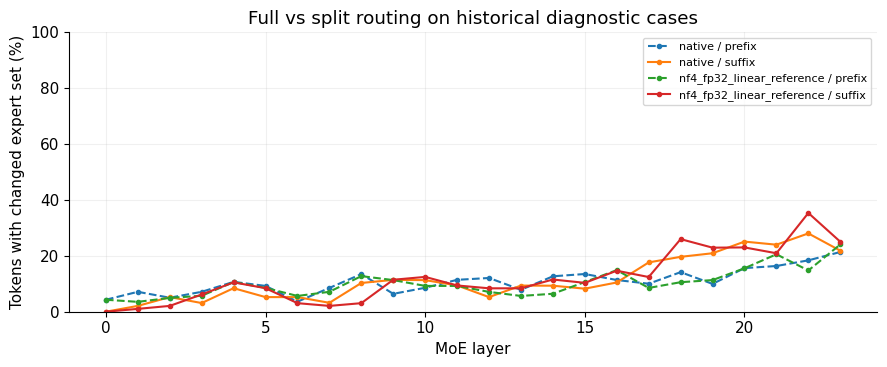

In [13]:
def common_prefix(lists):
    n=min(map(len,lists))
    for j in range(n):
        if len({v[j] for v in lists})>1:return lists[0][:j]
    return lists[0][:max(0,n-1)]

def cache_fingerprint(cache):
    h=hashlib.sha256()
    for layer in cache.layers:
        for t in (layer.keys,layer.values):
            if t is not None:
                h.update(str((tuple(t.shape),str(t.dtype))).encode())
                h.update(t.detach().contiguous().view(torch.uint8).cpu().numpy().tobytes())
    return int(cache.get_seq_length()),h.hexdigest()

@contextmanager
def nf4_linear_reference(enabled=False):
    # Diagnostic only: dequantize each Linear4bit on demand and use FP32 F.linear.
    # Weights remain the same NF4 codes; all other modules and output activations keep their dtype.
    saved=[]
    try:
        if enabled:
            import bitsandbytes as bnb
            for module in model.modules():
                if isinstance(module,bnb.nn.Linear4bit):
                    saved.append((module,module.forward))
                    def reference(this,x):
                        w=bnb.functional.dequantize_4bit(this.weight.data,this.weight.quant_state)
                        if tuple(w.shape)!=(this.out_features,this.in_features):
                            raise RuntimeError('Unexpected NF4 matrix layout; reference is not qualified.')
                        bias=this.bias.float() if this.bias is not None else None
                        return F.linear(x.float(),w.float(),bias).to(x.dtype)
                    module.forward=types.MethodType(reference,module)
            if not saved:raise RuntimeError('No Linear4bit modules found')
        yield
    finally:
        for module,forward in saved:module.forward=forward

class RouteCapture:
    def __init__(self):self.handles=[];self.values={}
    def __enter__(self):
        for i,block in MOES:
            def hook(module,args,out,i=i,k=block.top_k):
                p=out.detach().float().softmax(-1)
                val,idx=p.topk(min(k+1,p.shape[-1]),dim=-1)
                self.values[i]={'ids':idx[:,:k].sort(-1).values.cpu().numpy(),
                    'boundary_margin':(val[:,k-1]-val[:,k]).cpu().numpy() if k<p.shape[-1] else np.ones(len(val))}
            self.handles.append(block.gate.register_forward_hook(hook))
        return self
    def __exit__(self,*exc):
        for h in self.handles:h.remove()

@torch.inference_mode()
def cache_probe(group,mode):
    prepared=[prepare(r,'legacy') for r in group]
    prefix=common_prefix([ids for ids,_ in prepared]);assert prefix
    full=[];repeat=[];full_cache=[]
    for ids,codes in prepared:
        full.append(select_logits(forward_ids(ids),codes))
        repeat.append(select_logits(forward_ids(ids),codes))
        full_cache.append(select_logits(forward_ids(ids,use_cache=True),codes))
    root=forward_ids(prefix,use_cache=True).past_key_values
    before=cache_fingerprint(root)
    clone=copy.deepcopy(root)
    independent=all(a.data_ptr()!=b.data_ptr() for la,lb in zip(root.layers,clone.layers)
                    for a,b in [(la.keys,lb.keys),(la.values,lb.values)])
    del clone
    def branches(items):
        result=[]
        for ids,codes in items:
            branch=copy.deepcopy(root)
            out=forward_ids(ids[len(prefix):],cache=branch,use_cache=True)
            assert int(out.past_key_values.get_seq_length())==len(ids)
            result.append(select_logits(out,codes));del out,branch
        return result
    split=branches(prepared);reversed_split=branches(prepared[::-1])[::-1]
    intact=cache_fingerprint(root)==before
    checks=[]
    for r,a,b,c,d,e in zip(group,full,repeat,full_cache,split,reversed_split):
        pairs={'repeat':(a,b),'full_cache':(a,c),'split':(a,d),'reordered':(d,e),'full_vs_reordered':(a,e)}
        comparisons={name:{'max_dp':float(np.max(np.abs(probabilities(x)-probabilities(y)))),
                          'decision_match':bool(x.argmax()==y.argmax())} for name,(x,y) in pairs.items()}
        ok=independent and intact and all(v['max_dp']<=.005 and v['decision_match'] for v in comparisons.values())
        checks.append({'mode':mode,'id':r['id'],'prefix_tokens':len(prefix),'passed':ok,
          'cache_independent':independent,'cache_unchanged':intact,'comparisons':comparisons,
          'full_logits':a.tolist(),'split_logits':d.tolist()})
    # Locate routing changes for one predeclared case per source group, outside timing.
    ids,codes=prepared[min(2,len(prepared)-1)]
    with RouteCapture() as all_routes:forward_ids(ids)
    with RouteCapture() as prefix_routes:diagnostic_root=forward_ids(prefix,use_cache=True).past_key_values
    with RouteCapture() as suffix_routes:forward_ids(ids[len(prefix):],cache=diagnostic_root,use_cache=True)
    routing=[]
    for i,_ in MOES:
        baseline=all_routes.values[i]
        for region,ref,other in [('prefix',baseline['ids'][:len(prefix)],prefix_routes.values[i]),
                                 ('suffix',baseline['ids'][len(prefix):],suffix_routes.values[i])]:
            assert ref.shape==other['ids'].shape
            routing.append({'mode':mode,'id':group[min(2,len(group)-1)]['id'],'layer':i,'region':region,
                'tokens':len(ref),'changed_token_routes':int(np.any(ref!=other['ids'],axis=1).sum()),
                'min_router_boundary_margin':float(np.min(other['boundary_margin']))})
    del root,diagnostic_root
    return checks,routing

cache_checks=[];cache_routes=[];cache_errors=[]
if RUN_CACHE_NUMERICS:
    ids_wanted={x['id'] for x in PRIOR_PARITY}
    prior_groups=defaultdict(list)
    for r in PRIOR_ROWS:
        if r['id'] in ids_wanted:prior_groups[r['state_id']].append(r)
    modes=['native']
    if RUN_NF4_REFERENCE and not SMOKE and PRECISION=='nf4':modes.append('nf4_fp32_linear_reference')
    for mode in modes:
        print('Cache diagnostic:',mode,flush=True)
        try:
            with nf4_linear_reference(mode!='native'):
                for group in prior_groups.values():
                    result,routes=cache_probe(sorted(group,key=lambda r:r['id']),mode)
                    cache_checks.extend(result);cache_routes.extend(routes)
                    save_json('cache_numerics.json',{'checks':cache_checks,'routing':cache_routes,'errors':cache_errors})
        except Exception as exc:
            cache_errors.append({'mode':mode,'type':type(exc).__name__,'message':str(exc)})
        finally:
            gc.collect()
            if DEVICE.type=='cuda':torch.cuda.empty_cache()
            save_json('cache_numerics.json',{'checks':cache_checks,'routing':cache_routes,'errors':cache_errors})
cache_modes=[]
for mode in sorted({x['mode'] for x in cache_checks}):
    checks=[x for x in cache_checks if x['mode']==mode]
    cache_modes.append({'mode':mode,'checked':len(checks),'passed':sum(x['passed'] for x in checks),
        'max_dp':max(v['max_dp'] for x in checks for v in x['comparisons'].values()),
        'split_decision_flips':sum(not x['comparisons']['split']['decision_match'] for x in checks),
        'qualified_on_these_cases':all(x['passed'] for x in checks) and not any(e['mode']==mode for e in cache_errors)})
save_json('cache_mode_summary.json',{'modes':cache_modes,'errors':cache_errors,'cache_used_for_quality':False})
display(pd.DataFrame(cache_modes))
if cache_errors:print('Cache diagnostics recorded errors; independent full-input experiments continue:',cache_errors)
if cache_routes:
    frame=pd.DataFrame(cache_routes)
    frame['changed_fraction']=frame.changed_token_routes/frame.tokens
    fig,ax=plt.subplots(figsize=(9,3.8))
    for (mode,region),part in frame.groupby(['mode','region']):
        average=part.groupby('layer').changed_fraction.mean()
        ax.plot(average.index,average.values*100,label=mode+' / '+region,
                linestyle='--' if region=='prefix' else '-',marker='o',markersize=3)
    ax.set(xlabel='MoE layer',ylabel='Tokens with changed expert set (%)',ylim=(0,100),
           title=('SMOKE ONLY — ' if SMOKE else '')+'Full vs split routing on historical diagnostic cases')
    ax.legend(fontsize=8);fig.tight_layout();fig.savefig(RUN_DIR/'cache_route_changes.png',dpi=140);plt.show()

## 9. Select the prompt; fit calibration without hiding a ceiling

Prompt selection uses only `prompt_dev`. Later calibration minimizes NLL in inverse temperature β over [0,4], including β=0 (uniform probabilities). At that endpoint, the raw-logit argmax is the declared label tie-break; confidence remains uniform. This avoids the old T=5 upper ceiling while explicitly reporting a collapse to uniform uncertainty.

The prior native calibration-only refit favored T≈11.54, but its test NLL worsened from 0.9926 to 1.0093. Expanding the fit range is a methodological correction, **not a guaranteed quality gain**. The new fit uses fresh calibration states; review thresholds use different policy-development states. Zero coverage yields an undefined accepted-error rate, not zero error.

In [14]:
from scipy.optimize import minimize_scalar

def prediction_record(r,z,n_tokens,ms=None):
    keys=[o['id'] for o in r['options']]
    return {'id':r['id'],'state_id':r['state_id'],'family':r['family'],'split':r['split'],
        'target_id':r['target_id'],'target_index':keys.index(r['target_id']),'none_id':r['none_id'],
        'option_ids':keys,'logits':np.asarray(z).tolist(),'input_tokens':n_tokens,'latency_ms':ms or []}

def mean_nll(pred,beta=1.):
    return float(np.mean([-np.log(max(probabilities(x['logits'],beta)[x['target_index']],1e-300)) for x in pred]))

def fit_calibration(pred):
    # Convex scalar fit in inverse temperature. beta=0 explicitly includes uniform probabilities.
    objective=lambda beta:mean_nll(pred,beta)
    fit=minimize_scalar(objective,bounds=(0.,4.),method='bounded',options={'xatol':1e-10})
    beta=min([0.,float(fit.x),4.],key=objective)
    return {'inverse_temperature':beta,'temperature':1/beta if beta else None,
            'uniform_limit':beta==0,'upper_beta_boundary':abs(beta-4.)<1e-7,
            'calibration_nll':objective(beta),'n':len(pred)}

def outcome(x,beta):
    p=probabilities(x['logits'],beta)
    # Positive scaling preserves the label; at beta=0 keep the raw argmax as a declared tie-break.
    j=int(np.argmax(x['logits']))
    return p,j,float(p[j]),bool(j==x['target_index'])

def select_threshold(pred,beta,cost=REVIEW_COST):
    data=[outcome(x,beta) for x in pred]
    confidence=np.array([x[2] for x in data]);wrong=np.array([not x[3] for x in data])
    choices=np.unique(np.r_[0.,confidence,1.000001])
    def loss(t):
        accept=confidence>=t
        return float(np.mean(accept*wrong)+cost*np.mean(~accept)),-float(accept.mean())
    return float(min(choices,key=loss))

def metrics(pred,beta=1.,threshold=0.):
    outcomes=[outcome(x,beta) for x in pred]
    correct=np.array([v[3] for v in outcomes]);accept=np.array([v[2]>=threshold for v in outcomes])
    gold_none=np.array([x['target_id']==x['none_id'] for x in pred])
    predicted_none=np.array([x['option_ids'][v[1]]==x['none_id'] for x,v in zip(pred,outcomes)])
    times=[t for x in pred for t in x['latency_ms']]
    return {'n':len(pred),'states':len({x['state_id'] for x in pred}),'accuracy':float(correct.mean()),
        'nll':mean_nll(pred,beta),'none_recall':float(predicted_none[gold_none].mean()) if gold_none.any() else None,
        'false_none':float(predicted_none[~gold_none].mean()) if (~gold_none).any() else None,
        'brier':float(np.mean([np.sum((v[0]-np.eye(len(v[0]))[x['target_index']])**2) for x,v in zip(pred,outcomes)])),
        'coverage':float(accept.mean()),'accepted_n':int(accept.sum()),
        'accepted_error':float((~correct[accept]).mean()) if accept.any() else None,
        'review_cost':float(np.mean(accept*(~correct))+REVIEW_COST*np.mean(~accept)),
        'p50_ms':float(np.median(times)) if times else None,
        'p95_ms':float(np.percentile(times,95)) if times else None}

def collect(rows,settings=None,prompt_name=None,repeats=1):
    predictions=[]
    ordered=sorted(rows,key=lambda r:hashlib.sha256(r['id'].encode()).hexdigest())
    with intervention(**(settings or {})):
        for _ in range(WARMUP_CALLS):decision(ordered[0],prompt_name)
        for r in ordered:
            timings=[]
            for rep in range(repeats):
                sync();start=time.perf_counter();z,n=decision(r,prompt_name);sync()
                timings.append((time.perf_counter()-start)*1000)
                if rep==0:first=z.copy()
            predictions.append(prediction_record(r,first,n,timings))
    return predictions

prompt_results=[];prompt_predictions={}
for name in PROMPTS:
    pred=collect([r for r in ROWS if r['split']=='prompt_dev'],prompt_name=name)
    prompt_predictions[name]=pred
    prompt_results.append({'prompt':name,**metrics(pred)})
    save_json('prompt_development.json',{'results':prompt_results,'predictions':prompt_predictions})
# Select solely on prompt-development labels. Unknown recall resolves accuracy ties, then NLL.
winner=max(prompt_results,key=lambda x:(x['accuracy'],x['none_recall'],-x['nll'],x['prompt']=='legacy'))
SELECTED_PROMPT=winner['prompt']
save_json('prompt_lock.json',{'selected_prompt':SELECTED_PROMPT,'selection_split':'prompt_dev','results':prompt_results})
print('Locked prompt:',SELECTED_PROMPT)
display(pd.DataFrame(prompt_results)[['prompt','accuracy','none_recall','nll','p50_ms']])

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Locked prompt: explicit_three_way


,prompt,accuracy,none_recall,nll,p50_ms
0,legacy,0.458333,0.0,3.003873,1781.469988
1,explicit_three_way,0.458333,0.0,2.300047,1777.942215


## 10. Inspect the actual expert workload

Record token rows processed by each routed expert and the fraction of one-row calls. Capture an optional operator profile with shape information, then remove all instrumentation before timing. These observations can distinguish a broad prefill working set from small per-expert batches; they do not by themselves quantify CPU→GPU streaming costs or prove a kernel bottleneck.

In [15]:
profile_rows=[];handles=[]
try:
    for layer,block in MOES:
        for expert_id,expert in enumerate(block.experts):
            def before(module,args,layer=layer,expert_id=expert_id):
                profile_rows.append({'layer':layer,'expert':expert_id,'token_rows':int(args[0].shape[0])})
            handles.append(expert.register_forward_pre_hook(before))
    decision(probe)
finally:
    for h in handles:h.remove()
work=pd.DataFrame(profile_rows)
work.to_csv(RUN_DIR/'expert_batch_shapes.csv',index=False)
print('Mean unique experts/layer:',work.groupby('layer').expert.nunique().mean())
print('Fraction of expert calls with one token row:',float((work.token_rows==1).mean()))
print('Median token rows/expert call:',float(work.token_rows.median()))
if RUN_PROFILER:
    try:
        activities=[torch.profiler.ProfilerActivity.CPU]
        if DEVICE.type=='cuda':activities.append(torch.profiler.ProfilerActivity.CUDA)
        with torch.profiler.profile(activities=activities,record_shapes=True,profile_memory=False) as prof:
            with torch.profiler.record_function('complete_typed_decision'):decision(probe)
            sync()
        entries=[]
        for e in prof.key_averages():
            entries.append({'operation':e.key,'calls':e.count,'self_cpu_us':float(e.self_cpu_time_total),
                'self_device_us':float(getattr(e,'self_device_time_total',0.))})
        entries=sorted(entries,key=lambda e:e['self_device_us'] if DEVICE.type=='cuda' else e['self_cpu_us'],reverse=True)
        save_json('operator_profile.json',{'status':'captured','entries':entries,'timing_scope':'instrumented diagnostic only'})
        prof.export_chrome_trace(str(RUN_DIR/'operator_trace.json'))
        display(pd.DataFrame(entries[:12]))
    except Exception as exc:
        save_json('operator_profile.json',{'status':'unavailable','error':str(exc)})
        print('Profiler unavailable; ordinary timed experiments remain enabled:',type(exc).__name__)

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Mean unique experts/layer: 59.875
Fraction of expert calls with one token row: 0.015309672929714684
Median token rows/expert call: 11.0


/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


,operation,calls,self_cpu_us,self_device_us
0,complete_typed_decision,1,0.000,2807171.068
1,aten::mm,4390,179107.828,55988.617
2,bitsandbytes::dequantize_4bit,4413,215262.925,54293.869
3,"void kDequantizeBlockwise<__nv_bfloat16, 512, ...",4413,0.000,54293.869
4,void cutlass::Kernel2<cutlass_80_wmma_tensorop...,3392,0.000,39074.184
5,aten::index_add_,1437,18429.951,14764.178
6,void at::native::indexFuncSmallIndex<c10::BFlo...,1138,0.000,13716.013
7,aten::nonzero,1461,69841.962,13483.677
8,aten::index,4311,113511.331,12317.913
9,void cutlass::Kernel2<cutlass_80_wmma_tensorop...,848,0.000,10980.094


## 11. Select one intervention using development data

Compare native routing, skipping the last 1/2/4/6 MoE blocks, raw half-k, and the half-k scale control where applicable. No experts are deleted, so reduced allocated weight memory is not expected. Candidate selection is fixed before calibration/policy/final evaluation. The historical test set is never reused for this selection.

In [16]:
native_k=config.num_experts_per_tok
ARMS={'native':{}}
for n in sorted({min(v,len(MOES)-1) for v in SKIP_COUNTS}):
    if n>0:ARMS[f'skip_last_{n}']={'skip_count':n}
if native_k>1:
    ARMS['half_topk_raw']={'top_k':max(1,native_k//2)}
    if not config.norm_topk_prob and MASS_IMPLEMENTATION_OK:
        ARMS['half_topk_mass_matched']={'top_k':max(1,native_k//2),'mass_matched':True}
dev_rows=[r for r in ROWS if r['split']=='selection_dev']
development=[];development_predictions={}
for name,settings in ARMS.items():
    print('Development arm:',name,flush=True)
    pred=collect(dev_rows,settings)
    development_predictions[name]=pred
    development.append({'arm':name,**metrics(pred)})
    save_json('development_results.json',{'results':development,'predictions':development_predictions,'arms':ARMS})
native_dev=next(x for x in development if x['arm']=='native')
eligible=[x for x in development if x['arm']!='native'
    and x['accuracy']>=native_dev['accuracy']-DEV_MAX_ACCURACY_LOSS
    and x['none_recall']>=native_dev['none_recall']-DEV_MAX_NONE_RECALL_LOSS
    and native_dev['p50_ms']/x['p50_ms']>=MIN_SPEEDUP]
chosen=min(eligible,key=lambda x:x['p50_ms'])['arm'] if eligible else None
LOCK={'selected_prompt':SELECTED_PROMPT,'candidate':chosen,'candidate_settings':ARMS[chosen] if chosen else None,
      'selection_split':'selection_dev','eligible':[x['arm'] for x in eligible],
      'native_development':native_dev,'criterion':{'max_accuracy_loss':DEV_MAX_ACCURACY_LOSS,
        'max_none_recall_loss':DEV_MAX_NONE_RECALL_LOSS,'min_speedup':MIN_SPEEDUP},
      'fresh_data_sha256':MANIFEST['fresh_data_sha256'],'selected_at_utc':datetime.now(timezone.utc).isoformat()}
save_json('selection_lock.json',LOCK)
print('Locked candidate:',chosen or 'NONE — no arm met the development criteria')
display(pd.DataFrame(development)[['arm','accuracy','none_recall','nll','p50_ms']].round(4))

Development arm: native


/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Development arm: skip_last_1
Development arm: skip_last_2
Development arm: skip_last_4
Development arm: skip_last_6
Development arm: half_topk_raw
Development arm: half_topk_mass_matched
Locked candidate: skip_last_6


,arm,accuracy,none_recall,nll,p50_ms
0,native,0.3611,0.0000,2.0983,2023.8731
1,skip_last_1,0.3611,0.0000,3.0794,1948.1241
2,skip_last_2,0.3889,0.0000,3.4700,1868.3851
3,skip_last_4,0.4167,0.0833,2.6293,1700.8953
4,skip_last_6,0.3889,0.0000,2.4208,1532.5580
5,half_topk_raw,0.3889,0.0000,2.1217,1869.3234
6,half_topk_mass_matched,0.3889,0.0000,2.0377,1871.9114


## 12. Evaluate the locked candidate on fresh final cases

Fit one calibrator per arm on `calibration`, choose its review threshold on `policy_dev`, then evaluate native and the locked candidate on `test`. Alternate timed arm order per request. Report accuracy, unknown recall, false-unknown rate, NLL, Brier score, coverage, accepted error, latency and allocated memory.

The paired 95% bootstrap interval resamples **source states**, retaining related questions together. It is conditional on the selected candidate and these authored fixtures. Passing the displayed research gate motivates independent data collection; it never authorizes model promotion.

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Fresh final decisions: 12/96
Fresh final decisions: 24/96
Fresh final decisions: 36/96
Fresh final decisions: 48/96
Fresh final decisions: 60/96
Fresh final decisions: 72/96
Fresh final decisions: 84/96
Fresh final decisions: 96/96


,arm,n,states,accuracy,nll,none_recall,false_none,brier,coverage,accepted_n,accepted_error,review_cost,p50_ms,p95_ms,raw_nll,inverse_temperature,review_threshold,peak_allocated_gib,speedup_p50
0,native,96,32,0.3750,1.0836,0.0000,0.0,0.6564,0.1458,14,0.6429,0.1792,2022.4896,2048.3601,2.3083,0.0987,0.5071,7.8229,1.0000
1,skip_last_6,96,32,0.4167,1.0909,0.0625,0.0,0.6612,0.0833,8,0.3750,0.1229,1535.7819,1552.5181,2.3765,0.0739,0.4720,7.8228,1.3169


Paired state-bootstrap accuracy interval: {'unit': 'source state', 'states': 32, 'repetitions': 2000, 'accuracy_difference': 0.041666666666666664, 'ci95': [0.0, 0.10416666666666667], 'scope': 'paired nonparametric interval on authored fixtures; not a production guarantee'}


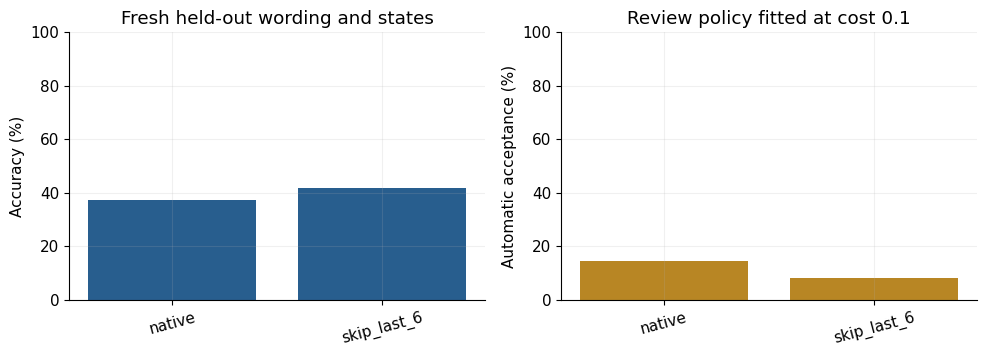

In [17]:
final_settings={'native':{}}
if chosen:final_settings[chosen]=ARMS[chosen]
calibrators={};thresholds={};final_predictions={name:[] for name in final_settings}
for name,settings in final_settings.items():
    cal=collect([r for r in ROWS if r['split']=='calibration'],settings)
    policy=collect([r for r in ROWS if r['split']=='policy_dev'],settings)
    calibration=fit_calibration(cal);beta=calibration['inverse_temperature']
    threshold=select_threshold(policy,beta)
    calibrators[name]=calibration;thresholds[name]=threshold
    save_json(name+'_calibration.json',{'calibrator':calibration,'review_threshold':threshold,
        'calibration_predictions':cal,'policy_predictions':policy,
        'policy_metrics':metrics(policy,beta,threshold)})

test_rows=sorted([r for r in ROWS if r['split']=='test'],key=lambda r:hashlib.sha256(r['id'].encode()).hexdigest())
# Interleave arms and alternate order. Timing excludes context-manager setup but includes tokenization,
# inference, synchronization and CPU logit transfer, matching the old request timing boundary.
peak_allocated={name:None for name in final_settings}
for name,settings in final_settings.items():
    with intervention(**settings):
        for _ in range(WARMUP_CALLS):decision(test_rows[0])
for index,r in enumerate(test_rows):
    times={name:[] for name in final_settings};first={};n_tokens={}
    for rep in range(TIMING_REPEATS):
        order=list(final_settings)
        if (index+rep)%2:order.reverse()
        for name in order:
            with intervention(**final_settings[name]):
                if DEVICE.type=='cuda':torch.cuda.reset_peak_memory_stats(DEVICE)
                sync();start=time.perf_counter();z,n=decision(r);sync()
                ms=(time.perf_counter()-start)*1000
                if DEVICE.type=='cuda':
                    peak_allocated[name]=max(peak_allocated[name] or 0.,torch.cuda.max_memory_allocated(DEVICE)/2**30)
            times[name].append(ms);n_tokens[name]=n
            if rep==0:first[name]=z.copy()
    for name in final_settings:
        final_predictions[name].append(prediction_record(r,first[name],n_tokens[name],times[name]))
    if (index+1)%12==0 or index+1==len(test_rows):
        save_json('final_predictions.json',final_predictions)
        print(f'Fresh final decisions: {index+1}/{len(test_rows)}',flush=True)

final_results=[]
for name,pred in final_predictions.items():
    beta=calibrators[name]['inverse_temperature'];threshold=thresholds[name]
    final_results.append({'arm':name,**metrics(pred,beta,threshold),
       'raw_nll':mean_nll(pred,1.),'inverse_temperature':beta,'review_threshold':threshold,
       'peak_allocated_gib':peak_allocated[name]})
base=next(x for x in final_results if x['arm']=='native')
for row in final_results:row['speedup_p50']=base['p50_ms']/row['p50_ms']

def paired_state_bootstrap(base_pred,other_pred):
    a={x['id']:x for x in base_pred};groups=defaultdict(list)
    for x in other_pred:
        base_x=a[x['id']]
        d=int(np.argmax(x['logits'])==x['target_index'])-int(np.argmax(base_x['logits'])==base_x['target_index'])
        groups[x['state_id']].append(d)
    groups=list(groups.values());rng=np.random.default_rng(SEED)
    samples=[]
    for _ in range(BOOTSTRAP_REPEATS):
        selected=rng.integers(0,len(groups),len(groups))
        samples.append(float(np.mean([d for i in selected for d in groups[i]])))
    return {'unit':'source state','states':len(groups),'repetitions':BOOTSTRAP_REPEATS,
        'accuracy_difference':float(np.mean([d for g in groups for d in g])),
        'ci95':[float(v) for v in np.quantile(samples,[.025,.975])],
        'scope':'paired nonparametric interval on authored fixtures; not a production guarantee'}

paired=paired_state_bootstrap(final_predictions['native'],final_predictions[chosen]) if chosen else None
candidate_result=next((x for x in final_results if x['arm']==chosen),None)
research_gate=False
if candidate_result is not None:
    c=candidate_result
    research_gate=(c['accuracy']>=MIN_FINAL_ACCURACY and c['none_recall']>=MIN_FINAL_NONE_RECALL
        and c['coverage']>=MIN_FINAL_COVERAGE and c['accepted_error'] is not None
        and c['accepted_error']<=MAX_FINAL_ACCEPTED_ERROR and c['speedup_p50']>=MIN_SPEEDUP
        and paired['ci95'][0]>=-DEV_MAX_ACCURACY_LOSS)
save_json('final_results.json',{'results':final_results,'paired_accuracy_interval':paired,
    'research_gate_passed':research_gate,'promotion_authorized':False,'smoke_only':SMOKE})
pd.DataFrame(final_results).to_csv(RUN_DIR/'final_results.csv',index=False)
display(pd.DataFrame(final_results).round(4))
if paired:print('Paired state-bootstrap accuracy interval:',paired)

# Keep the decline-to-decide result visible, even when every item goes to review.
fig,axes=plt.subplots(1,2,figsize=(10,3.7))
labels=[x['arm'] for x in final_results]
axes[0].bar(labels,[100*x['accuracy'] for x in final_results],color=BLUE)
axes[0].set(ylim=(0,100),ylabel='Accuracy (%)',title='Fresh held-out wording and states')
axes[1].bar(labels,[100*x['coverage'] for x in final_results],color=GOLD)
axes[1].set(ylim=(0,100),ylabel='Automatic acceptance (%)',title=f'Review policy fitted at cost {REVIEW_COST}')
for ax in axes:ax.tick_params(axis='x',labelrotation=15)
if SMOKE:fig.suptitle('SMOKE ONLY — tiny random weights; not Qwen capability measurements')
fig.tight_layout();fig.savefig(RUN_DIR/'fresh_quality_and_coverage.png',dpi=140);plt.show()

## 13. Check option order and preserve the evidence

Apply one predeclared cyclic option permutation to 12 final questions per arm. Compare semantic option IDs after remapping. This is a robustness diagnostic; it cannot trigger reselection on the final set. Export source provenance, locks, predictions, cache diagnostics, expert shapes, plots, a readable run summary and SHA-256 checksums to a ZIP beside the persistent run folder.

In [18]:
order_results=[]
if RUN_OPTION_ORDER_CHECK:
    # Fixed diagnostic sample, not used for prompt/arm/calibration selection.
    for name,settings in final_settings.items():
        prior={p['id']:p for p in final_predictions[name]}
        beta=calibrators[name]['inverse_temperature']
        with intervention(**settings):
            for r in sorted(test_rows,key=lambda x:x['id'])[:12]:
                rr=copy.deepcopy(r);rr['options']=rr['options'][1:]+rr['options'][:1]
                z,_=decision(rr);old=prior[r['id']]
                old_p=dict(zip(old['option_ids'],probabilities(old['logits'],beta)))
                new_keys=[o['id'] for o in rr['options']];new_p=dict(zip(new_keys,probabilities(z,beta)))
                order_results.append({'arm':name,'id':r['id'],
                    'same_semantic_choice':old['option_ids'][np.argmax(old['logits'])]==new_keys[np.argmax(z)],
                    'max_calibrated_dp':max(abs(old_p[k]-new_p[k]) for k in old_p)})
save_json('option_order_diagnostic.json',order_results)
summary={'schema':'openkind-moe-quality-cache-followup/v1','status':'SMOKE_ONLY' if SMOKE else 'EXPLORATORY_COMPLETE',
    'historical_drive_run':'20260926T224132_613995Z','historical_completed_run_available':False,
    'profile':PROFILE,'model_id':MANIFEST['model_id'],'model_revision':REVISION,
    'prompt_lock':SELECTED_PROMPT,'selected_candidate':chosen,'results':final_results,
    'cache_modes':cache_modes,'cache_errors':cache_errors,'cache_used_for_quality':False,
    'research_gate_passed':bool(research_gate and not SMOKE),'model_promoted':False,
    'paired_accuracy_interval':paired,
    'limitations':['Fresh data are authored fixtures, not independent production/benchmark evidence',
      'Historical Drive run is incomplete; the later pasted physical-removal result lacks raw Drive artifacts',
      'NF4 FP32 linear reference retains NF4 weights and lower-precision surrounding operations',
      'No actual expert streaming, distillation, weight pruning, or Qwen3.5 hybrid-cache execution',
      'Hook/eager runtime is not a grouped-expert serving speed ceiling']}
save_json('summary.json',summary)
MANIFEST.update(completed_utc=datetime.now(timezone.utc).isoformat(),selected_candidate=chosen)
save_json('manifest.json',MANIFEST)
notes=['# Follow-up run summary','',f'**Status:** {summary["status"]}',
       f'**Model:** {MANIFEST["model_id"]} at {REVISION}',f'**Selected prompt:** {SELECTED_PROMPT}',
       f'**Development-selected candidate:** {chosen}',f'**Research gate:** {summary["research_gate_passed"]}',
       '', 'All quality/timing results use full-input execution. Cache diagnostics are separate.',
       '', '| Arm | Accuracy | Unknown recall | Coverage | Accepted error | p50 ms |',
       '|---|---:|---:|---:|---:|---:|']
for x in final_results:
    err='undefined (zero accepted)' if x['accepted_error'] is None else f'{x["accepted_error"]:.3f}'
    notes.append(f'| {x["arm"]} | {x["accuracy"]:.3f} | {x["none_recall"]:.3f} | {x["coverage"]:.3f} | {err} | {x["p50_ms"]:.1f} |')
notes+=['','## Limits',*['- '+x for x in summary['limitations']]]
(RUN_DIR/'RUN_SUMMARY.md').write_text('\n'.join(notes)+'\n')
artifacts=sorted(p for p in RUN_DIR.rglob('*') if p.is_file() and p.name!='SHA256SUMS')
(RUN_DIR/'SHA256SUMS').write_text(''.join(hashlib.sha256(p.read_bytes()).hexdigest()+'  '+str(p.relative_to(RUN_DIR))+'\n' for p in artifacts))
archive=shutil.make_archive(str(RUN_DIR),'zip',RUN_DIR)
print('Run status:',summary['status'],'| research gate:',summary['research_gate_passed'])
print('Evidence archive:',archive)
if DOWNLOAD_ARCHIVE and not SMOKE:
    from google.colab import files
    files.download(archive)

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:464: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Run status: EXPLORATORY_COMPLETE | research gate: False
Evidence archive: /content/drive/MyDrive/Colab Notebooks/OpenKind_MoE_Lab/followup_runs/20260927T003918_481825Z.zip


## Interpretation and next decision

- **Native unknown recall stays poor:** focus on decision supervision/data and model suitability; a temperature cannot recover missing classification ability.
- **Mass-matched half-k beats raw half-k:** scale contributed to the regression on these inputs. Missing-expert content can still matter; no general recovery is established.
- **A late-block candidate survives fresh quality and uncertainty checks:** lock it and collect independent domain data before training or deployment.
- **FP32 NF4-linear reference changes cache behavior:** numerical implementation deserves further isolation. It does not validate the native fast path.
- **Nearly all experts still appear in prefill:** evaluate actual working-set residency/transfer measurements before pursuing a streaming engine. Per-token top-k alone is insufficient.

**Primary implementation references:** [Transformers Qwen2 MoE 4.57.1](https://github.com/huggingface/transformers/blob/v4.57.1/src/transformers/models/qwen2_moe/modeling_qwen2_moe.py), [Qwen3 MoE 4.57.1](https://github.com/huggingface/transformers/blob/v4.57.1/src/transformers/models/qwen3_moe/modeling_qwen3_moe.py), [bitsandbytes 0.48.1 dispatch](https://github.com/bitsandbytes-foundation/bitsandbytes/blob/0.48.1/bitsandbytes/autograd/_functions.py), [bitsandbytes Linear4bit](https://github.com/bitsandbytes-foundation/bitsandbytes/blob/0.48.1/bitsandbytes/nn/modules.py), [Transformers cache positions/masks](https://huggingface.co/docs/transformers/v4.57.1/en/cache_explanation), and [PyTorch numerical accuracy](https://docs.pytorch.org/docs/stable/notes/numerical_accuracy.html).

**Validation boundary:** source-file hashes and original metrics were checked locally. This notebook's tiny random Qwen2/Qwen3 paths, intervention restoration, calibration, export and failure handling are exercised locally. The actual pretrained GPU, bitsandbytes linear-reference, and Colab Drive mount paths require your runtime. The notebook contains no invented new pretrained results.